In [37]:
import os
import grid2op
from grid2op.Action import PlayableAction
from l2rpn_baselines.OptimCVXPY import OptimCVXPY
from lightsim2grid import LightSimBackend
from tqdm import tqdm
from grid2op.PlotGrid import PlotMatplot

In [38]:
# Create environment
env = grid2op.make("educ_case14_storage",
                       test=True,
                       backend=LightSimBackend(),
                       action_class=PlayableAction)

# Create CVXPY agent
optim_agent = OptimCVXPY(env.action_space,
                    env,
                    penalty_redispatching_unsafe=0.,
                    penalty_storage_unsafe=0.04,
                    penalty_curtailment_unsafe=0.01,
                    rho_safe=0.95,
                    rho_danger=0.97,
                    margin_th_limit=0.93,
                    alpha_por_error=0.5,
                    weight_redisp_target=0.3,
                    )
# in safe / recovery mode agent tries to fill the storage units as much as possible
optim_agent.storage_setpoint = env.storage_Emax

# Create DoNothing agent
dn_agent = grid2op.Agent.DoNothingAgent(env.action_space)

d:\AIPlan4Grid\.venv\lib\site-packages\grid2op\MakeEnv\Make.py:393: UserWarning: You are using a development environment. This environment is not intended for training agents. It might not be up to date and its primary use if for tests (hence the "test=True" you passed as argument). Use at your own risk.
  warnings.warn(_MAKE_DEV_ENV_WARN)


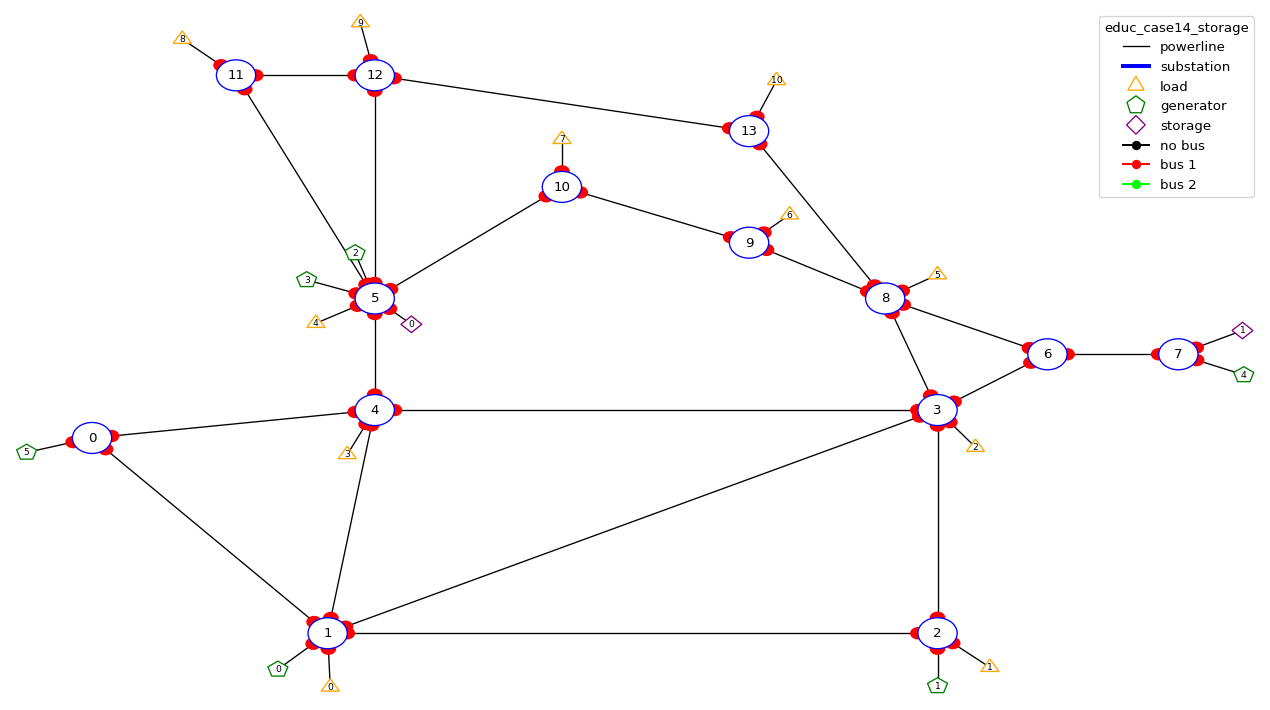

In [39]:
# Plot the instance
plot_helper = PlotMatplot(env.observation_space)
fig = plot_helper.plot_layout()

In [40]:
# set the max number of time steps the agent can take and the scenario
max_step = 288
scen_id = 5

For do nothing: 


 81%|████████  | 233/288 [00:00<00:00, 1387.54it/s]


	 scenario: 2019-01-17: 234 / 288
	 cumulated reward: 3546.45


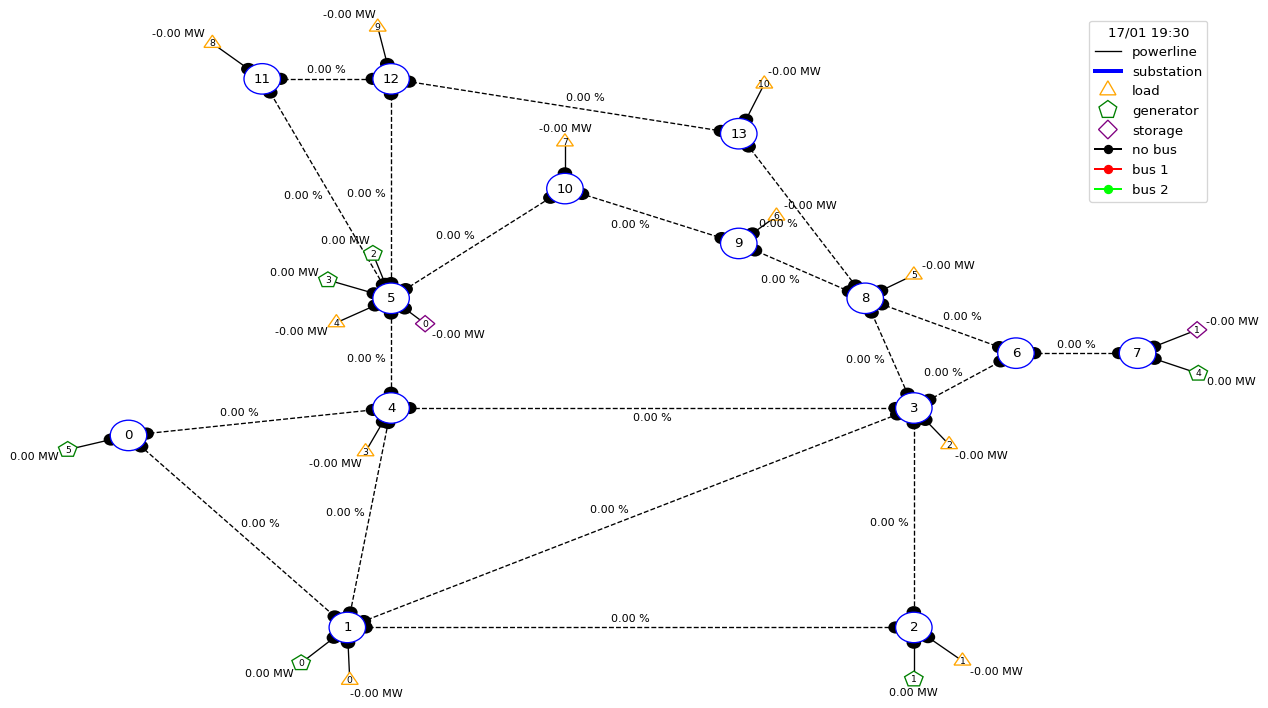

In [41]:
print("For do nothing: ")
env.set_id(scen_id)
obs = env.reset()
done = False
all_obs = []
cum_reward = 0
for nb_step in tqdm(range(max_step)):
    dn_act = dn_agent.act(obs, reward, done)
    obs, reward, done, info = env.step(dn_act)
    cum_reward += reward
    all_obs.append(obs)
    if done and nb_step != (max_step-1):
        break
print(f"\t scenario: {os.path.split(env.chronics_handler.get_id())[-1]}: {nb_step + 1} / {max_step}")
print(f"\t cumulated reward: {cum_reward:.2f}")
last_obs = all_obs[-1]
_ = plot_helper.plot_obs(last_obs)

Blackout!

For the optimizer: 


100%|██████████| 288/288 [00:18<00:00, 15.97it/s]


	 scenario: 2019-01-17: 288 / 288
	 cumulated reward: 4304.58


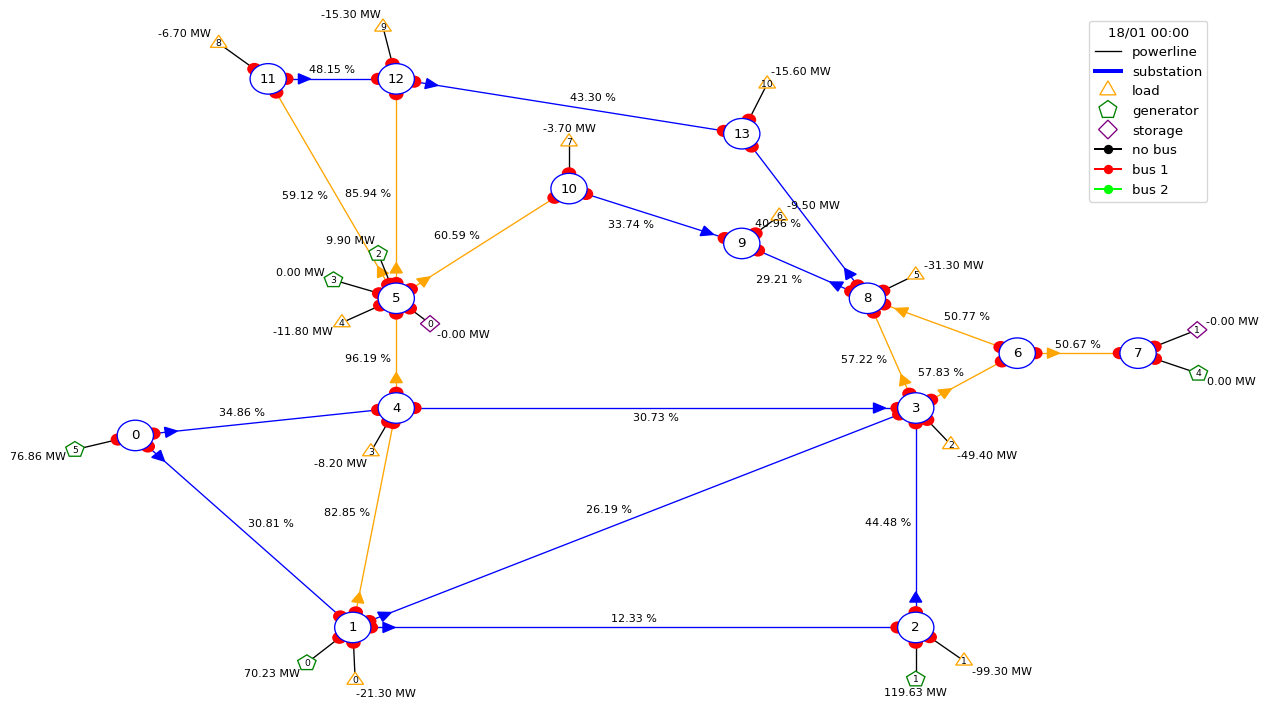

In [42]:
print("For the optimizer: ")
env.set_id(scen_id)
obs = env.reset()
optim_agent.reset(obs)
done = False
all_obs = []
cum_reward = 0
for nb_step in tqdm(range(max_step)):
    prev_obs = obs
    act = optim_agent.act(obs)
    obs, reward, done, info = env.step(act)
    cum_reward += reward
    all_obs.append(obs)
    if done and nb_step != (max_step-1):
        # there is a game over before the end
        break
print(f"\t scenario: {os.path.split(env.chronics_handler.get_id())[-1]}: {nb_step + 1} / {max_step}")
print(f"\t cumulated reward: {cum_reward:.2f}")
last_obs = all_obs[-1]
_ = plot_helper.plot_obs(last_obs)

The network is safe.